# Polynomial Regression

Polynomial regression addresses two limitations of the Linear Regression
1. fitting the data, by addin higher order
2. interaction among the different features

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../../jupyter_notebooks/08-Linear-Regression-Models/Advertising.csv')
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
X=df.drop('sales',axis=1)

In [5]:
y = df['sales']

In [6]:
from sklearn.preprocessing import PolynomialFeatures

In [7]:
polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)

In [8]:
polynomial_converter.fit(X)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [9]:
poly_features = polynomial_converter.transform(X)

In [10]:
poly_features.shape

(200, 9)

The 9 columns correspond to:
1. the three original features
2. the three interaction features: TV*radio, TV*newspaper, radio*newspaper
3. the squares of the three features

In [11]:
# There is also a fit + transform method, since it is so common to first fit to the existing features and later transform to generate the polynomial features.
polynomial_converter.fit_transform(X)

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]],
      shape=(200, 9))

It is worth keeping in mind that when we persist the trained model --as we did with thee Linear Regression model-- we will have to persist the polynomial converter too, since it will be needed to transfrom any new data with only three features into the nine features needed.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
# the "Polynomial step" is now by feeding the Linear Regression with the Polynomial features
X_train,X_test,y_train,y_test=train_test_split(poly_features, y, test_size=0.3,random_state=101)

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
test_predictions = model.predict(X_test)

In [18]:
mod_coefs = model.coef_
# there are nine coeficients
mod_coefs

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [19]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [20]:
MAE = mean_absolute_error(y_test,test_predictions)

In [21]:
MSE = mean_squared_error(y_test,test_predictions)

In [22]:
RMSE = np.sqrt(MSE)

In [23]:
MAE

0.48967980448035886

In [24]:
RMSE

np.float64(0.6646431757269)

Now, if we compare this errors with those of the simple Linear Regression we'll see that they are smaller: this polynomial model is better at predicting.

Polynomial is better, but up to which degree? to know that, we can run a loop that

1.for each increasing polynomial order
* create the polynomial model
* split in polynomial train/test set
* fit on train data
* calculate the Root Mean Squared Error for both train and test set (avoid overfitting)
* Plot the results error versus polynomial order


In [25]:
train_rmse_errors = []
test_rmse_errors = []
for d in range(1,10): # overkill to have a 10-degree polynomial for a 3-features data set, but for explanatory purposes:
    poly_converter=PolynomialFeatures(degree=d,include_bias=False)
    poly_features = poly_converter.fit_transform(X)
    X_train,X_test,y_train,y_test=train_test_split(poly_features, y, test_size=0.3,random_state=101)
    model = LinearRegression()
    model.fit(X_train,y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(y_train,train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test,test_pred))
    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)


In [26]:
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292234),
 np.float64(0.43393443569020657),
 np.float64(0.35170836883993556),
 np.float64(0.2509342923820358),
 np.float64(0.20953728417844544),
 np.float64(0.22046859203477034),
 np.float64(0.2715007492459394),
 np.float64(0.5132041534764287)]

In [27]:
test_rmse_errors

[np.float64(1.5161519375993877),
 np.float64(0.6646431757269),
 np.float64(0.5803286825219469),
 np.float64(0.5077742640851456),
 np.float64(2.575819395346124),
 np.float64(9.87141294832405),
 np.float64(41.33052000561568),
 np.float64(3108.590753416225),
 np.float64(12767.649350474843)]

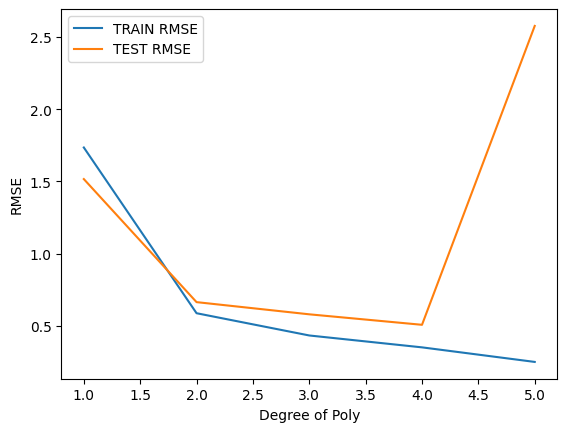

In [28]:
plt.plot(range(1,6),train_rmse_errors[:5],label='TRAIN RMSE')
plt.plot(range(1,6),test_rmse_errors[:5],label='TEST RMSE')
plt.ylabel('RMSE')
plt.xlabel('Degree of Poly')
plt.legend()

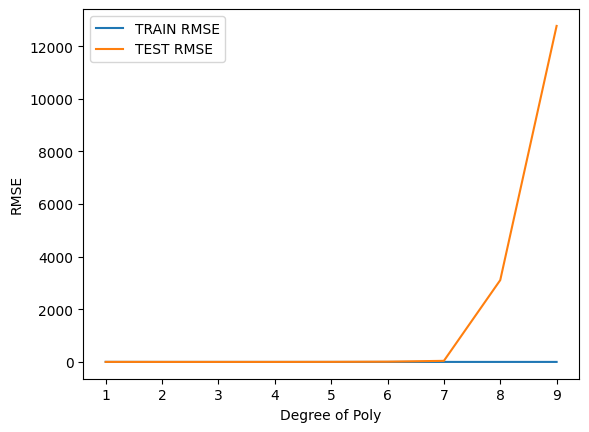

In [29]:
## Let's see how far it goes if you overdo the polynomial order
plt.plot(range(1,10),train_rmse_errors,label='TRAIN RMSE')
plt.plot(range(1,10),test_rmse_errors,label='TEST RMSE')
plt.ylabel('RMSE')
plt.xlabel('Degree of Poly')
plt.legend()

# Polynomial regression model deployment

## Save the model and converter

In [30]:
final_poly_converter = PolynomialFeatures(degree=3,include_bias=False)

In [31]:
final_model = LinearRegression()

In [32]:
full_converted_X = final_poly_converter.fit_transform(X)
final_model.fit(full_converted_X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
from joblib import dump,load

In [34]:
# Save the model
dump(final_model,'final_poly_model.joblib')

['final_poly_model.joblib']

In [35]:
# Save the converter
dump(final_poly_converter, 'final_converter.joblib')

['final_converter.joblib']

## Load model and converter to predict sales

### new campaign

In [36]:
# data from a new campaign, for which you want to predict sales
campaign = [[149,22,12]]

### Load model and converter

In [37]:
loaded_converter = load('final_converter.joblib')
loaded_model = load('final_poly_model.joblib')

### Create polynomial features from new data

In [38]:
transformed_data = loaded_converter.fit_transform(campaign)

### Predict sales from poly features

In [39]:
loaded_model.predict(transformed_data)

array([14.64501014])

Much better prediction than with the linear regression model.

In [40]:
predd = loaded_model.predict(transformed_data)

In [41]:
predd

array([14.64501014])

In [42]:
predd[0]

np.float64(14.645010135430303)

In [52]:
if isinstance(predd[0], float):
    print("Yes it is float")
else:
    print("No, it is not a float")

Yes it is float
